- Voornaam:
- Achternaam:
- Klasgroep:

In dit document zet je alle antwoorden. We houden geen rekening met antwoorden op het papieren examenblad.

In [2]:
#PLAATS HIER AL JE IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, classification_report, ConfusionMatrixDisplay, root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import validation_curve  

from tensorflow.keras import Model  
from tensorflow.keras.layers import Input, Dense  
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from simanneal import Annealer


# Vraag 1



In [ ]:
#a
#(39, 7)

In [ ]:
#b
#df.iloc[13, [5]]

In [ ]:
#c
#df.loc[[20:22], ['re', 'mi', 'fa', 'sol']]

In [ ]:
#d
#[]

In [ ]:
#e
# gemid = df.loc[20:30, ['Age']].mean()
#print(gemid)

# Vraag 2


In [3]:
#dataset inlezen
df = pd.read_csv('student_habits.csv', sep=",", decimal=".")

df.head(5)

,Age,StudyHours,GamingHours,SleepHours,SocialActivity,AcademicPerformance,GamingSkill,PassFail
0,21,0.6,9.0,7.0,0,62.0,65.5,Fail
1,19,37.3,9.3,7.2,7,109.5,58.8,Pass
2,21,20.0,11.9,7.1,4,94.0,61.7,Pass
3,21,21.6,12.8,7.4,2,91.3,74.1,Pass
4,19,27.4,24.0,5.1,9,78.1,98.5,Not participated


In [15]:
#gemiddeld aantal studieuren uit de passfail
avg_studyhours_p_passfail = df.groupby('PassFail')['StudyHours'].mean()
print(avg_studyhours_p_passfail)

PassFail
Fail                 7.361176
Not participated    19.454967
Pass                25.052273
Name: StudyHours, dtype: float64


# Vraag 3 




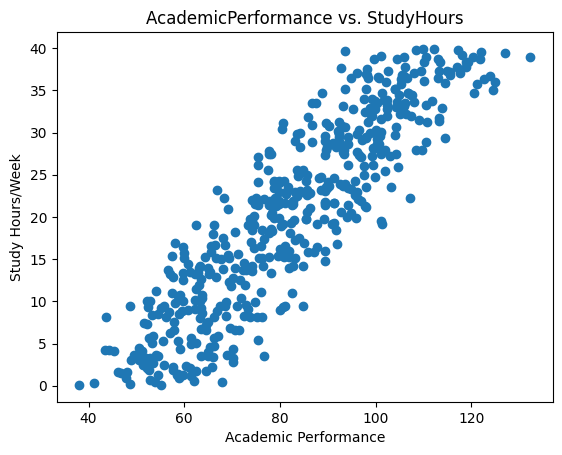

In [22]:
#scatterplot
plt.scatter(x=df['AcademicPerformance'], y=df['StudyHours'])
plt.title('AcademicPerformance vs. StudyHours')
plt.xlabel('Academic Performance')
plt.ylabel('Study Hours/Week')
plt.show()

# Vraag 4


In [6]:
#a

#predictors
X = df[['StudyHours', 'SleepHours', 'SocialActivity', 'GamingHours']] 

#target feature
y = df['AcademicPerformance'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [7]:
#b
def polynomial_regression(degree=2, **kwargs):  
    model = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression(**kwargs))  
    return model

degree = np.arange(2, 4)
model = polynomial_regression()

train_score, val_score = validation_curve(model, X, y, param_name='polynomialfeatures__degree', param_range=degree, cv=5)

In [8]:
#c
print(f'Train mean R2 scores      : {train_score.mean(axis=1)}')  
print(f'Validation mean R2 scores : {val_score.mean(axis=1)}')

grid_param = {'polynomialfeatures__degree': np.arange(1, 10), 'linearregression__fit_intercept': [True, False]}
grid = GridSearchCV(model, param_grid=grid_param, cv=7)

grid.fit(X, y)

print(grid.best_params_)
print(grid.best_score_)

Train mean R2 scores      : [0.93651926 0.93898989]
Validation mean R2 scores : [0.92969836 0.92463945]
{'linearregression__fit_intercept': True, 'polynomialfeatures__degree': 1}
0.9319531687646999


# Vraag 5

In [9]:
#a

#predictors
X = df[['Age', 'StudyHours', 'GamingHours', 'SleepHours', 'SocialActivity']]
#target feature
y = df['PassFail']

scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_norm, y, train_size=0.2, random_state=42)

In [25]:
#b
inputs = Input(shape=(5,))

x = Dense(128, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)

total_output_neurons = pd.unique(y).size
outputs = Dense(total_output_neurons, activation='softmax')(x)

model = Model(inputs, outputs, name="STUHABNN")
model.summary()

model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

Model: "STUHABNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,219 (36.01 KB)

 Trainable params: 9,219 (36.01 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#c
#lib is ineens verdwenen : ( tijdens het examen --> heb code gebaseerd op de oefeningen die ik heb gemaakt heb het de toezicht docent verteld
#alvast bedankt om hier rekening mee te houden! : |
from plot_loss import plot_loss

history = model.fit(x_train, y_train, epochs=40, batch_size=32, validaiton_split=0.2)

ModuleNotFoundError: No module named 'plot_loss'

In [11]:
#d
plot_loss(history)
#vanaf 100 epocht

NameError: name 'plot_loss' is not defined

In [ ]:
#e
student_12356 = pd.DataFrame({'Age': [20],'StudyHours': [15],'GamingHours': [5],'SleepHours': [7],'SocialActivity': [10]})
new_data_norm = scaler.transform(student_12356)
predicted_outcome = model.predict(new_data_norm)

#zal de voorspelde failpass tonen voor de nieuwe student
print(predicted_outcome)

NotFittedError: This PolynomialFeatures instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

# Vraag 6

In [13]:
import numpy as np
from simanneal import Annealer

# Genereer willekeurige beloningen en hoogtes voor de posities
np.random.seed(42)  # Voor reproduceerbaarheid
reward_values = np.random.randint(10, 101, size=10)  # Waarden van de beloningen
reward_heights = np.random.randint(1, 101, size=10)  # Hoogtes van de beloningen

class MarioJumpProblem(Annealer):
    def energy(self):
        jump_heights = self.state #De huigide oplossing
        total_jump_force = sum(jump_heights) #De totale sprongkracht van mario
        catched = np.where(jump_heights-reward_heights >= 0,1,0)  # Een array waarbij 1 betekent dat de sprong hoog genoeg is om de beloning te vangen. vb. [1, 0, 1, 0, 1, 0, 1, 0, 1, 0] betekent dat de sprongen hoog genoeg zijn  voor de beloningen op positie 0,2,4,6 en 8.
        #(Ter info: De where-functie werkt als een voorwaardelijke if-statement. Als aan de voorwaarde voldaan is, dan wordt de waarde 1 toegekend, anders 0.)

         ###VUL HIER AAN###
        if total_jump_force > 600 or jump_heights > 600:
            return 90000000

        return -catched

    def move(self): # Verhoog/verlaag een willekeurige spronghoogte met 0 tot 20 meter
        a = np.random.randint(0, len(self.state))

        if self.state[a] == 0:
            self.state[a] = 1
        else:
            self.state[a] = 0

#Een oplossing is een array van random spronghoogtes tussen 0 en 100 meter. vb. [65, 32, 30, 10, 89, 64, 58, 10, 95, 3]
init_sol = np.random.randint(0, 101, size=10)  # Random spronghoogtes

In [14]:
mario_problem = MarioJumpProblem(init_sol)
jumpval = mario_problem.anneal()

print(f'De array voor de optimale jumpt voor Mario:\n'
      f'{jumpval[0]}')

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()